## Importing libraries

In [ ]:

import tensorflow as tf
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models
from torch_geometric.data import Data, DataLoader
from torch_geometric.nn import GATConv, global_mean_pool
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, roc_curve, auc, cohen_kappa_score
from sklearn.preprocessing import label_binarize

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


data = tf.keras.utils.image_dataset_from_directory(
    directory='D1',
    image_size=(224,224),
    batch_size=64,
    label_mode='int',
    shuffle=True,
    seed=42
)


data_list = list(data.unbatch())
np.random.shuffle(data_list)

dataset_size = len(data_list)
train_size = int(0.7 * dataset_size)
val_size   = int(0.2 * dataset_size)

train_data = data_list[:train_size]
val_data   = data_list[train_size:train_size+val_size]
test_data  = data_list[train_size+val_size:]

def list_to_numpy(data_list):
    images, labels = [], []
    for x, y in data_list:
        images.append(x.numpy())
        labels.append(y.numpy())
    return np.array(images), np.array(labels)

train_images, train_labels = list_to_numpy(train_data)
val_images, val_labels     = list_to_numpy(val_data)
test_images, test_labels   = list_to_numpy(test_data)

print("Train:", len(train_images))
print("Val:", len(val_images))
print("Test:", len(test_images))


class CNNEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        resnet = models.resnet50(weights="IMAGENET1K_V2")
        self.features = nn.Sequential(*list(resnet.children())[:-1])  # remove FC
        
    def forward(self, x):
        x = self.features(x)
        return x.view(x.size(0), -1)   # [B, 2048]

cnn = CNNEncoder().to(device)
cnn.eval()


# IMAGE TO GRAPH

def image_to_graph(img, patch_size=32):
    """
    Convert 224x224 image into graph of 49 nodes (7x7 patches)
    Each node = ResNet50 features
    """
    img = torch.tensor(img, dtype=torch.float32).permute(2,0,1) / 255.0
    
    patches = []
    for i in range(0,224,patch_size):
        for j in range(0,224,patch_size):
            patch = img[:, i:i+patch_size, j:j+patch_size]
            patch = F.interpolate(patch.unsqueeze(0), size=(224,224))
            
            with torch.no_grad():
                feat = cnn(patch.to(device)).cpu().squeeze(0)  # [2048]
            
            patches.append(feat)
    
    x = torch.stack(patches)  # [49, 2048]
    
    # Grid edges
    edges = []
    n = 7
    for i in range(n):
        for j in range(n):
            idx = i*n + j
            if j+1 < n:
                edges.append([idx, idx+1])
                edges.append([idx+1, idx])
            if i+1 < n:
                edges.append([idx, idx+n])
                edges.append([idx+n, idx])

    edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
    return x, edge_index


def build_loader(images, labels, shuffle=True):
    graphs = []
    for i in range(len(images)):
        x, edge_index = image_to_graph(images[i])
        y = torch.tensor(labels[i], dtype=torch.long)
        graphs.append(Data(x=x, edge_index=edge_index, y=y))
    return DataLoader(graphs, batch_size=8, shuffle=shuffle)

train_loader = build_loader(train_images, train_labels, True)
val_loader   = build_loader(val_images, val_labels, False)
test_loader  = build_loader(test_images, test_labels, False)


# GAT MODEL

class GAT_Model(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.gat1 = GATConv(2048, 256, heads=4)  # output = 1024
        self.gat2 = GATConv(1024, 256, heads=1)  # output = 256
        
        self.fc = nn.Linear(256, 4)  # CORAL: 5 classes => 4 outputs
        
    def forward(self, x, edge_index, batch):
        x = F.elu(self.gat1(x, edge_index))
        x = F.elu(self.gat2(x, edge_index))
        x = global_mean_pool(x, batch)
        return self.fc(x)

model = GAT_Model().to(device)


# CORAL LOSS

def coral_loss(logits, labels):
    K = logits.size(1) + 1
    target = torch.zeros((labels.size(0), K-1), device=labels.device)
    
    for i in range(K-1):
        target[:, i] = (labels > i).float()
    
    return F.binary_cross_entropy_with_logits(logits, target)

def coral_to_label(logits):
    probs = torch.sigmoid(logits)
    return torch.sum(probs > 0.5, dim=1)


# TRAIN MODEL

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

train_losses = []
val_losses = []

for epoch in range(10):
    
    # ---- TRAIN ----
    model.train()
    total_train_loss = 0
    
    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        
        logits = model(batch.x, batch.edge_index, batch.batch)
        loss = coral_loss(logits, batch.y)
        
        loss.backward()
        optimizer.step()
        
        total_train_loss += loss.item()
    
    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    # ---- VALIDATION ----
    model.eval()
    total_val_loss = 0
    
    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(device)
            logits = model(batch.x, batch.edge_index, batch.batch)
            loss = coral_loss(logits, batch.y)
            total_val_loss += loss.item()
    
    avg_val_loss = total_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    
    print(f"Epoch {epoch+1}: Train Loss = {avg_train_loss:.4f}, Val Loss = {avg_val_loss:.4f}")


plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()


model.eval()
y_true = []
y_pred = []
y_prob = []

with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        logits = model(batch.x, batch.edge_index, batch.batch)
        
        probs = torch.sigmoid(logits)
        preds = coral_to_label(logits)
        
        y_true.extend(batch.y.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())
        y_prob.extend(probs.cpu().numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)


qwk = cohen_kappa_score(y_true, y_pred, weights='quadratic')
print("QWK:", round(qwk,4))
plt.show()

Using device: cpu
Found 3662 files belonging to 5 classes.
Train: 2563
Val: 732
Test: 367


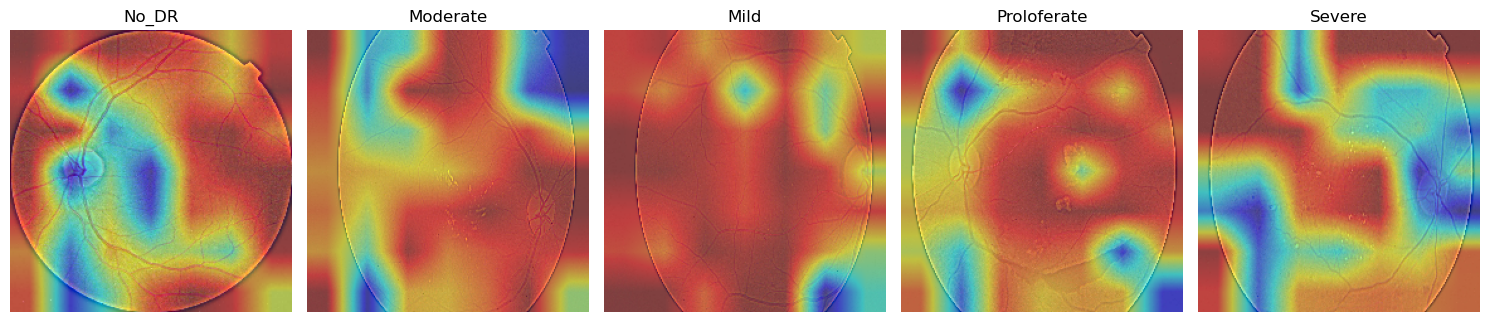

In [29]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        
        self.gradients = None
        self.activations = None
        
       
        target_layer.register_forward_hook(self.save_activation)
        
      
        target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate(self, input_tensor, class_idx):
        self.model.zero_grad()

        output = self.model(input_tensor)
        loss = output[:, class_idx]
        loss.backward()

        grads = self.gradients
        activations = self.activations

        # Global Average Pooling on gradients
        weights = torch.mean(grads, dim=(2,3), keepdim=True)

        cam = torch.sum(weights * activations, dim=1)

        cam = F.relu(cam)
        cam = cam.squeeze().cpu().detach().numpy()

        cam = (cam - cam.min()) / (cam.max() + 1e-8)

        return cam

class ResNet50Classifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = models.resnet50(weights="IMAGENET1K_V2")
        self.model.fc = nn.Linear(2048, 5)  

    def forward(self, x):
        return self.model(x)

grad_model = ResNet50Classifier().to(device)
grad_model.eval()

def get_one_per_class(images, labels):
    selected = {}
    
    for img, label in zip(images, labels):
        if label not in selected:
            selected[label] = img
        if len(selected) == 5:
            break
    
    return selected

sample_images = get_one_per_class(test_images, test_labels)

target_layer = grad_model.model.layer4[-1]
cam = GradCAM(grad_model, target_layer)

import cv2

def show_cam(image, cam_map, title="Grad-CAM"):
    img = (image / 255.0)
    
    cam_map = cv2.resize(cam_map, (224,224))
    heatmap = cv2.applyColorMap(np.uint8(255*cam_map), cv2.COLORMAP_JET)
    heatmap = heatmap / 255.0
    
    overlay = heatmap + img
    overlay = overlay / np.max(overlay)
    
    plt.imshow(overlay)
    plt.title(title)
    plt.axis('off')

    class_names = ['Mild', 'Moderate', 'No_DR', 'Proliferate', 'Severe']

plt.figure(figsize=(15,5))

for i, (label, img) in enumerate(sample_images.items()):
    
    input_tensor = torch.tensor(img, dtype=torch.float32).permute(2,0,1).unsqueeze(0).to(device) / 255.0
    
    output = grad_model(input_tensor)
    pred_class = torch.argmax(output).item()
    
    cam_map = cam.generate(input_tensor, pred_class)
    
    plt.subplot(1,5,i+1)
    show_cam(img, cam_map, f"{class_names[label]}")

plt.tight_layout()
plt.show()

In [31]:
def get_gat_attention(model, data):
  
    model.eval()
    
    with torch.no_grad():
        x, edge_index, batch = data.x, data.edge_index, data.batch
        
        # Get attention weights
        out, (edge_idx, attn_weights) = model.gat2(
            x, edge_index, return_attention_weights=True
        )
        
        # Average attention per node
        node_scores = torch.zeros(x.size(0)).to(x.device)
        
        for i in range(edge_idx.size(1)):
            src = edge_idx[0, i]
            node_scores[src] += attn_weights[i]
        
        node_scores = node_scores / (node_scores.max() + 1e-8)
        
    return node_scores.cpu().numpy()
        

In [32]:
def map_nodes_to_image(node_scores, grid_size=7):
 
    node_map = node_scores.reshape(grid_size, grid_size)

    # Upsample to image size
    node_map = cv2.resize(node_map, (224, 224))

    # Normalize
    node_map = (node_map - node_map.min()) / (node_map.max() + 1e-8)

    return node_map

In [33]:
def fuse_maps(cam_map, gat_map, alpha=0.6):
  
    fused = alpha * cam_map + (1 - alpha) * gat_map
    
    fused = (fused - fused.min()) / (fused.max() + 1e-8)
    
    return fused

In [34]:
def show_fusion(image, cam_map, gat_map, fused_map, title="Fusion"):

    img = image / 255.0

    def overlay(map_):
        heatmap = cv2.applyColorMap(np.uint8(255 * map_), cv2.COLORMAP_JET)
        heatmap = heatmap / 255.0
        out = heatmap + img
        return out / np.max(out)

    plt.figure(figsize=(12,4))

    plt.subplot(1,4,1)
    plt.imshow(img)
    plt.title("Original")
    plt.axis('off')

    plt.subplot(1,4,2)
    plt.imshow(overlay(cam_map))
    plt.title("Grad-CAM")
    plt.axis('off')

    plt.subplot(1,4,3)
    plt.imshow(overlay(gat_map))
    plt.title("GAT Attention")
    plt.axis('off')

    plt.subplot(1,4,4)
    plt.imshow(overlay(fused_map))
    plt.title("Fusion")
    plt.axis('off')

    plt.suptitle(title)
    plt.show()

In [35]:
def visualize_combined(model_gat, grad_model, image, label, device):

    # -------- Grad-CAM --------
    input_tensor = torch.tensor(image, dtype=torch.float32)\
        .permute(2,0,1).unsqueeze(0).to(device) / 255.0

    output = grad_model(input_tensor)
    pred_class = torch.argmax(output).item()

    cam_map = cam.generate(input_tensor, pred_class)

    # -------- GAT --------
    x, edge_index = image_to_graph(image)
    batch = torch.zeros(x.size(0), dtype=torch.long)

    data = Data(x=x.to(device), edge_index=edge_index.to(device), batch=batch.to(device))

    node_scores = get_gat_attention(model_gat, data)
    gat_map = map_nodes_to_image(node_scores)

    # -------- Fusion --------
    fused_map = fuse_maps(cam_map, gat_map, alpha=0.6)

    # -------- Show --------
    show_fusion(image, cam_map, gat_map, fused_map,
                title=f"Label: {label}")

Found 3662 files belonging to 5 classes.
Epoch 1 done
Epoch 2 done
Epoch 3 done


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [47.0..255.0].


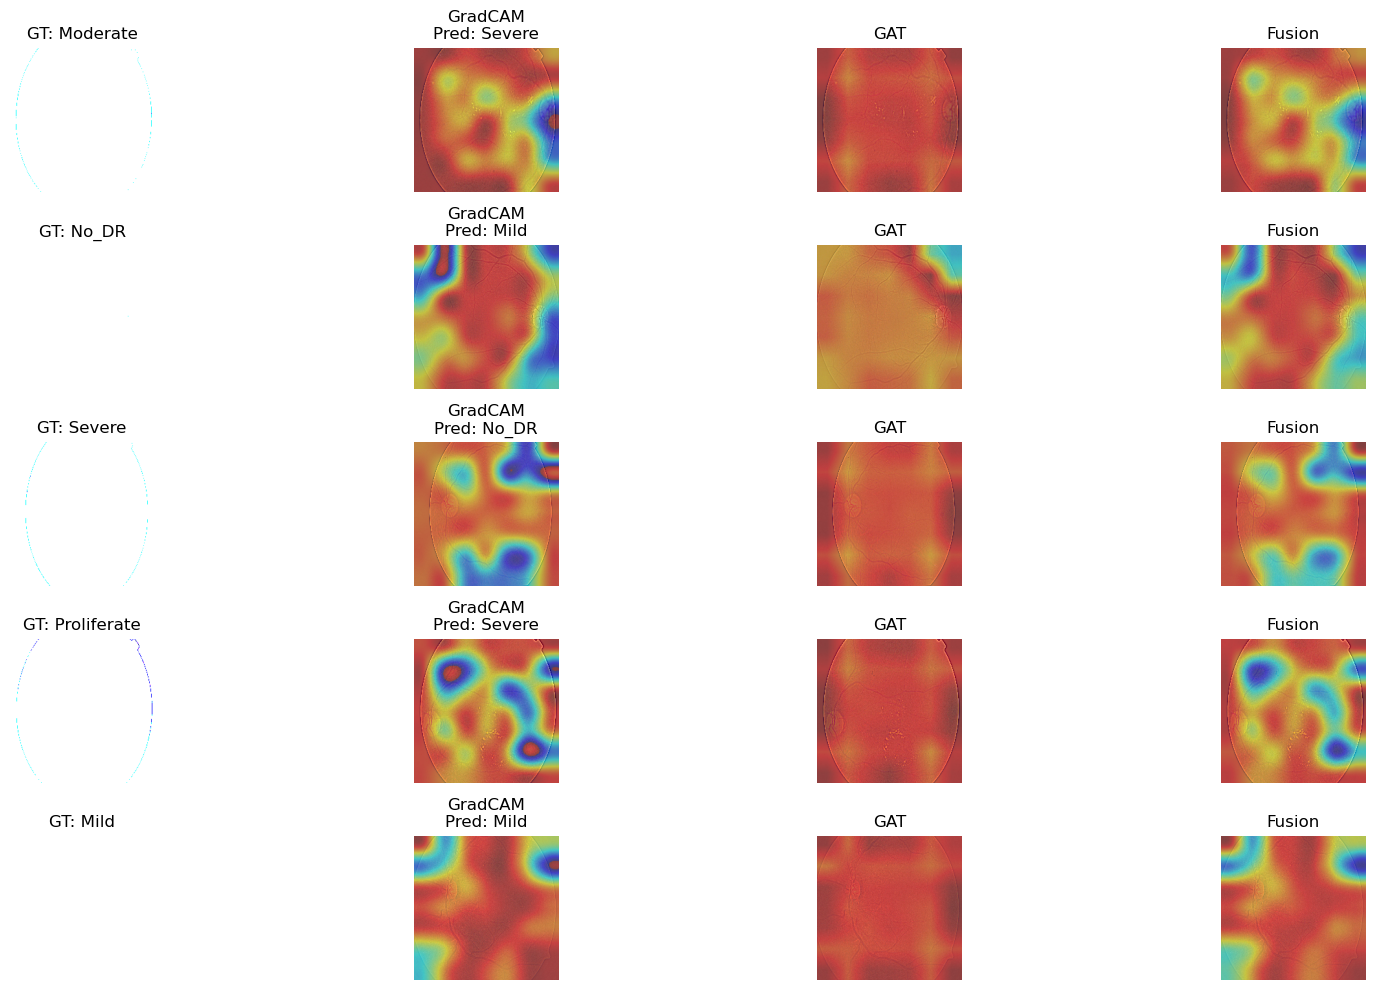

In [39]:

import tensorflow as tf
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models
from torch_geometric.data import Data, DataLoader
from torch_geometric.nn import GATConv, global_mean_pool
import matplotlib.pyplot as plt
import cv2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


data = tf.keras.utils.image_dataset_from_directory(
    'D1',
    image_size=(224,224),
    batch_size=32,
    label_mode='int',
    shuffle=True
)

data_list = list(data.unbatch())
np.random.shuffle(data_list)

train_size = int(0.7 * len(data_list))
train_data = data_list[:train_size]
test_data = data_list[train_size:]

def to_numpy(data_list):
    imgs, lbls = [], []
    for x,y in data_list:
        imgs.append(x.numpy())
        lbls.append(y.numpy())
    return np.array(imgs), np.array(lbls)

train_images, train_labels = to_numpy(train_data)
test_images, test_labels = to_numpy(test_data)


class ResNet50Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        resnet = models.resnet50(weights="IMAGENET1K_V2")
        self.features = nn.Sequential(*list(resnet.children())[:-1])

    def forward(self, x):
        x = self.features(x)
        return x.view(x.size(0), -1)

cnn = ResNet50Encoder().to(device)
cnn.eval()


def image_to_graph(img):
    img = torch.tensor(img, dtype=torch.float32).permute(2,0,1)/255.0
    
    patches = []
    for i in range(0,224,32):
        for j in range(0,224,32):
            patch = img[:, i:i+32, j:j+32]
            patch = F.interpolate(patch.unsqueeze(0), size=(224,224))
            
            with torch.no_grad():
                feat = cnn(patch.to(device)).cpu().squeeze(0)
            
            patches.append(feat)
    
    x = torch.stack(patches)  # [49,2048]

    edges = []
    n = 7
    for i in range(n):
        for j in range(n):
            idx = i*n + j
            if j+1<n:
                edges.append([idx, idx+1])
                edges.append([idx+1, idx])
            if i+1<n:
                edges.append([idx, idx+n])
                edges.append([idx+n, idx])
    
    edge_index = torch.tensor(edges).t().contiguous()
    return x, edge_index


def build_loader(images, labels):
    graphs = []
    for i in range(len(images)):
        x, edge_index = image_to_graph(images[i])
        y = torch.tensor(labels[i], dtype=torch.long)
        graphs.append(Data(x=x, edge_index=edge_index, y=y))
    return DataLoader(graphs, batch_size=8, shuffle=True)

train_loader = build_loader(train_images, train_labels)


class GAT_Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.gat1 = GATConv(2048, 256, heads=4)   # → 1024
        self.gat2 = GATConv(1024, 128)            # correct
        self.fc = nn.Linear(128, 4)               # CORAL

    def forward(self, x, edge_index, batch):
        x = F.elu(self.gat1(x, edge_index))
        x, (edge_idx, attn) = self.gat2(
            x, edge_index, return_attention_weights=True
        )
        x = F.elu(x)
        self.attn = attn
        self.edge_idx = edge_idx
        x = global_mean_pool(x, batch)
        return self.fc(x)

model = GAT_Model().to(device)


def coral_loss(logits, labels):
    K = logits.size(1)+1
    target = torch.zeros((labels.size(0), K-1)).to(device)
    
    for i in range(K-1):
        target[:,i] = (labels>i).float()
    
    return F.binary_cross_entropy_with_logits(logits, target)

def coral_to_label(logits):
    probs = torch.sigmoid(logits)
    return torch.sum(probs>0.5, dim=1)


optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

for epoch in range(3):
    model.train()
    for data in train_loader:
        data = data.to(device)
        optimizer.zero_grad()
        out = model(data.x, data.edge_index, data.batch)
        loss = coral_loss(out, data.y)
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1} done")


class GradCAM:
    def __init__(self, model, layer):
        self.model = model
        self.activations = None
        self.gradients = None
        
        layer.register_forward_hook(self.save_activation)
        layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate(self, x, cls):
        self.model.zero_grad()
        out = self.model(x)
        loss = out[:,cls].sum()
        loss.backward()
        
        weights = torch.mean(self.gradients, dim=(2,3), keepdim=True)
        cam = torch.sum(weights * self.activations, dim=1)
        cam = F.relu(cam).squeeze().cpu().detach().numpy()


        cam = cv2.resize(cam, (224,224), interpolation=cv2.INTER_CUBIC)

        cam = (cam - cam.min())/(cam.max()+1e-8)

        return cam

grad_model = models.resnet50(weights="IMAGENET1K_V2").to(device)
grad_model.fc = nn.Linear(2048,5)
grad_model.eval()

cam = GradCAM(grad_model, grad_model.layer4[-1])


def get_one_per_class(images, labels):
    selected = {}
    for img, lbl in zip(images, labels):
        if lbl not in selected:
            selected[lbl] = img
        if len(selected)==5:
            break
    return selected

def nodes_to_map(node_scores):
    node_map = node_scores.reshape(7,7)
    node_map = cv2.resize(node_map, (224,224))
    return (node_map - node_map.min())/(node_map.max()+1e-8)

def fuse(cam_map, gat_map):
    # ensure both are same size
    cam_map = cv2.resize(cam_map, (224,224))
    gat_map = cv2.resize(gat_map, (224,224))

    fused = 0.6*cam_map + 0.4*gat_map
    return (fused - fused.min())/(fused.max()+1e-8)

def overlay(img, heatmap):
    img = img/255.0
    heatmap = cv2.applyColorMap(np.uint8(255*heatmap), cv2.COLORMAP_JET)/255.0
    out = heatmap + img
    return out/np.max(out)

# VISUALIZATION 
class_names = ['Mild','Moderate','No_DR','Proliferate','Severe']

samples = get_one_per_class(test_images, test_labels)

plt.figure(figsize=(18,10))

for i,(label,img) in enumerate(samples.items()):

    # GradCAM
    inp = torch.tensor(img, dtype=torch.float32)\
        .permute(2,0,1).unsqueeze(0).to(device)/255.0
    
    pred = torch.argmax(grad_model(inp)).item()
    cam_map = cam.generate(inp, pred)

    # GAT
    x, edge_index = image_to_graph(img)
    batch = torch.zeros(x.size(0), dtype=torch.long)

    data = Data(x=x.to(device),
                edge_index=edge_index.to(device),
                batch=batch.to(device))

    _ = model(data.x, data.edge_index, data.batch)

    attn = model.attn.detach().cpu().numpy()
    edge_idx = model.edge_idx.cpu().numpy()

    node_scores = np.zeros(x.shape[0])
    for j in range(edge_idx.shape[1]):
        src = edge_idx[0,j]
        node_scores[src] += np.mean(attn[j])

    node_scores /= (node_scores.max()+1e-8)

    gat_map = nodes_to_map(node_scores)

    # Fusion
    fused = fuse(cam_map, gat_map)

    # Plot
    plt.subplot(5,4,i*4+1)
    plt.imshow(img)
    plt.title(f"GT: {class_names[label]}")
    plt.axis('off')

    plt.subplot(5,4,i*4+2)
    plt.imshow(overlay(img, cam_map))
    plt.title(f"GradCAM\nPred: {class_names[pred]}")
    plt.axis('off')

    plt.subplot(5,4,i*4+3)
    plt.imshow(overlay(img, gat_map))
    plt.title("GAT")
    plt.axis('off')

    plt.subplot(5,4,i*4+4)
    plt.imshow(overlay(img, fused))
    plt.title("Fusion")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
import warnings
import cv2
import os
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
warnings.filterwarnings('ignore')
# import visualkeras
import matplotlib.pyplot as plt

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from torchvision import models, transforms
from torch_geometric.data import Data, DataLoader
from torch_geometric.nn import GATConv, global_mean_pool
from sklearn.metrics import cohen_kappa_score
import cv2
import matplotlib.pyplot as plt

In [6]:
import tensorflow as tf; print(tf.__version__)

2.21.0


# TensorFlow pipeline
We will create a dataset pipeline from our data using tensorflow dataset api

TensorFlow has a dataset api that supports writing descriptive and efficient input pipelines. a common pattern is to
- Create a source dataset from your input data.
- Apply dataset transformations to preprocess the data.
- Iterate over the dataset and process the elements.

[For more information](https://www.tensorflow.org/api_docs/python/tf/data/Dataset)

In [3]:
# generating dataset from directory

# Generating train dataset
data = tf.keras.utils.image_dataset_from_directory(directory = 'DRM',
                                                   color_mode = 'rgb',
                                                   batch_size = 64,
                                                   image_size = (224,224),
                                                   shuffle=True,
                                                   seed = 2022)

Found 1272 files belonging to 5 classes.


## Displaying data distribution

In [4]:
labels = np.concatenate([y for x,y in data], axis=0)

In [5]:
values = pd.value_counts(labels)
values = values.sort_index()

In [6]:
values

0    236
1    240
2    271
3    245
4    280
Name: count, dtype: int64

### Checking labels

In [7]:
# getting class names
class_names = data.class_names
for idx, name in enumerate(class_names):
  print(f"{idx} = {name}", end=", ")

0 = Mild, 1 = Moderate, 2 = No_DR, 3 = Proloferate, 4 = Severe, 

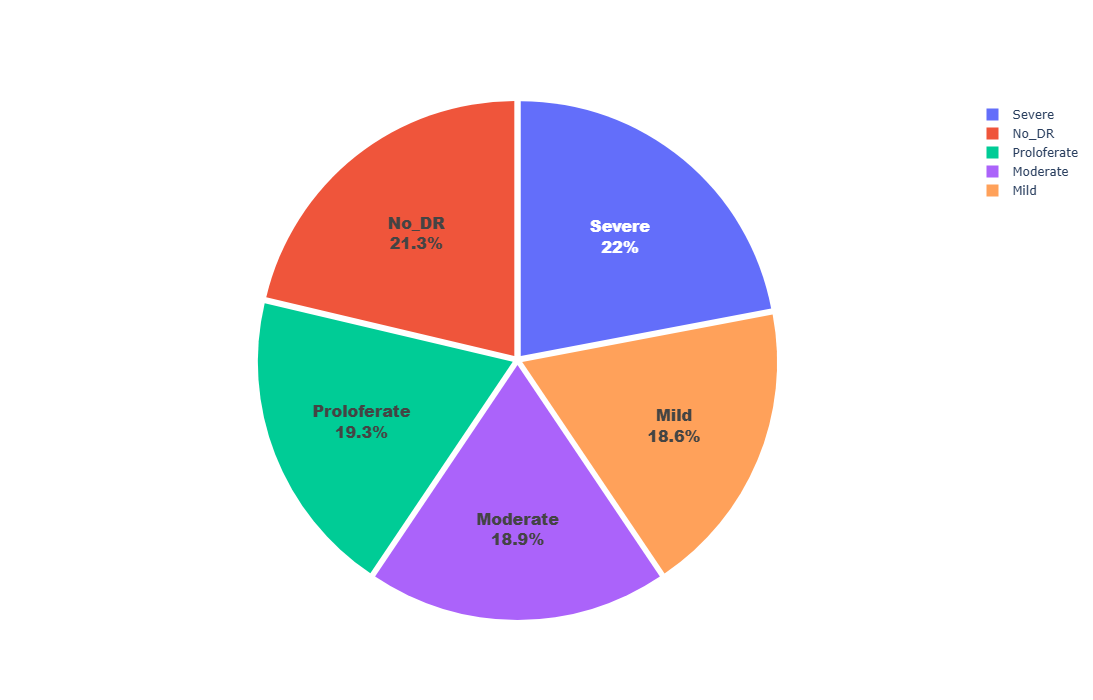

In [8]:
import plotly.graph_objects as go

fig = go.Figure(
    data=go.Pie(
        labels=data.class_names,
        values=values,
        textinfo='percent+label',
        pull=[0.02] * len(data.class_names),
        textfont=dict(
            size=16,
            family="Arial Black"  # or "Calibri Bold", "Times New Roman Bold"
        )
    )
)
fig.update_layout(width=1000, height=700)
fig.show()

In [9]:
data_iterator = data.as_numpy_iterator()

In [10]:
batch = data_iterator.next()

In [11]:
batch[0].shape

(64, 224, 224, 3)

In [13]:
data = data.map(lambda x, y: (x/255, y))

In [14]:
sample = data.as_numpy_iterator().next()

In [15]:
print(sample[0].min())
print(sample[0].max())

0.0
1.0


In [16]:
print("Total number of batchs = ",len(data))

Total number of batchs =  20


In [17]:
train_size = int(0.7 * len(data)) +1
val_size = int(0.2 * len(data))
test_size = int(0.1 * len(data))

In [18]:
train = data.take(train_size)
remaining = data.skip(train_size)
val = remaining.take(val_size)
test = remaining.skip(val_size)

In [19]:
print(f"# train batchs = {len(train)}, # validate batchs = {len(val)}, # test batch = {len(test)}")
len(train) + len(val) + len(test)

# train batchs = 15, # validate batchs = 4, # test batch = 1


20

In [18]:
def extract_patches(img, patch_size=32):
    C, H, W = img.shape
    patches = []
    coords = []
    
    for i in range(0, H, patch_size):
        for j in range(0, W, patch_size):
            patch = img[:, i:i+patch_size, j:j+patch_size]
            patches.append(patch)
            coords.append((i, j))
    
    return patches, coords

In [19]:
def lesion_score(patch):
    patch_np = patch.permute(1,2,0).cpu().numpy()
    gray = cv2.cvtColor((patch_np*255).astype(np.uint8), cv2.COLOR_RGB2GRAY)
    
    # simple proxy: high variance = lesions
    return np.var(gray)

In [20]:
def image_to_graph(img, cnn, device):
    patches, coords = extract_patches(img)
    
    features = []
    weights = []
    
    for p in patches:
        p_resized = F.interpolate(p.unsqueeze(0), size=(224,224))
        feat = cnn(p_resized.to(device)).squeeze(0)
        features.append(feat)
        weights.append(lesion_score(p))
    
    x = torch.stack(features)
    weights = torch.tensor(weights)
    
    # Spatial edges
    n = int(np.sqrt(len(patches)))
    edges = []
    
    for i in range(n):
        for j in range(n):
            idx = i*n + j
            
            if j+1 < n:
                edges.append([idx, idx+1])
                edges.append([idx+1, idx])
            if i+1 < n:
                edges.append([idx, idx+n])
                edges.append([idx+n, idx])
    
    edge_index = torch.tensor(edges).t().contiguous()
    
    return x.detach(), edge_index, weights

In [21]:
class CNNEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        resnet = models.resnet18(weights="IMAGENET1K_V1")
        self.features = nn.Sequential(*list(resnet.children())[:-1])
        self.out_dim = 512

    def forward(self, x):
        x = self.features(x)
        return x.view(x.size(0), -1)

In [22]:
class GAT_Model(nn.Module):
    def __init__(self, in_dim=512, hidden=128, num_classes=5):
        super().__init__()
        
        self.gat1 = GATConv(in_dim, hidden, heads=4, concat=True)
        self.gat2 = GATConv(hidden*4, hidden, heads=1, concat=False)
        
        self.fc = nn.Linear(hidden, num_classes-1)  # CORAL

    def forward(self, x, edge_index, batch):
        x = F.elu(self.gat1(x, edge_index))
        x = F.elu(self.gat2(x, edge_index))
        
        x = global_mean_pool(x, batch)
        logits = self.fc(x)
        return logits

In [23]:
def coral_loss(logits, labels):
    K = logits.size(1) + 1
    
    target = torch.zeros((labels.size(0), K-1), device=labels.device)
    
    for i in range(K-1):
        target[:, i] = (labels > i).float()
    
    return F.binary_cross_entropy_with_logits(logits, target)

In [24]:
def qwk(y_true, y_pred):
    return cohen_kappa_score(y_true, y_pred, weights='quadratic')

In [25]:
def coral_to_label(logits):
    probs = torch.sigmoid(logits)
    return torch.sum(probs > 0.5, dim=1)

In [26]:
def train(model, loader, optimizer, device):
    model.train()
    total_loss = 0
    
    for data in loader:
        data = data.to(device)
        optimizer.zero_grad()
        
        logits = model(data.x, data.edge_index, data.batch)
        loss = coral_loss(logits, data.y)
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    return total_loss / len(loader)

In [27]:
def evaluate(model, loader, device):
    model.eval()
    y_true, y_pred = [], []
    
    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            logits = model(data.x, data.edge_index, data.batch)
            
            preds = coral_to_label(logits)
            
            y_true.extend(data.y.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
    
    return qwk(y_true, y_pred)

In [28]:
def visualize_attention(image, node_importance, patch_size=32):
    H, W = image.shape[1], image.shape[2]
    heatmap = np.zeros((H, W))
    
    idx = 0
    for i in range(0, H, patch_size):
        for j in range(0, W, patch_size):
            heatmap[i:i+patch_size, j:j+patch_size] = node_importance[idx]
            idx += 1
    
    plt.imshow(image.permute(1,2,0))
    plt.imshow(heatmap, cmap='jet', alpha=0.5)
    plt.title("Attention Heatmap")
    plt.show()

In [29]:
data = data.unbatch()
data = data.shuffle(1000, seed=42)

dataset_size = data.cardinality().numpy()

train_size = int(0.7 * dataset_size)
val_size = int(0.2 * dataset_size)
test_size = dataset_size - train_size - val_size

train = data.take(train_size)
remaining = data.skip(train_size)

val = remaining.take(val_size)
test = remaining.skip(val_size)

# Re-batch
train = train.batch(64)
val = val.batch(64)
test = test.batch(64)

In [30]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
import seaborn as sns

def train_model(model, train_loader, val_loader, optimizer, device, epochs=10):
    train_losses, val_losses = [], []
    qwk_scores = []

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for data in train_loader:
            data = data.to(device)
            optimizer.zero_grad()

            logits = model(data.x, data.edge_index, data.batch)
            loss = coral_loss(logits, data.y)

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_train_loss = total_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # Validation
        val_loss, qwk_score = evaluate_model(model, val_loader, device)
        val_losses.append(val_loss)
        qwk_scores.append(qwk_score)

        print(f"Epoch {epoch+1}")
        print(f"Train Loss: {avg_train_loss:.4f}")
        print(f"Val Loss: {val_loss:.4f} | QWK: {qwk_score:.4f}")
        print("-"*40)

    return train_losses, val_losses, qwk_scores

In [31]:
def evaluate_model(model, loader, device):
    model.eval()
    total_loss = 0
    y_true, y_pred = [], []

    with torch.no_grad():
        for data in loader:
            data = data.to(device)

            logits = model(data.x, data.edge_index, data.batch)
            loss = coral_loss(logits, data.y)

            preds = coral_to_label(logits)

            total_loss += loss.item()
            y_true.extend(data.y.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    avg_loss = total_loss / len(loader)
    qwk_score = qwk(y_true, y_pred)

    return avg_loss, qwk_score

In [32]:
def test_model(model, loader, device):
    model.eval()
    y_true, y_pred, y_prob = [], [], []

    with torch.no_grad():
        for data in loader:
            data = data.to(device)

            logits = model(data.x, data.edge_index, data.batch)
            probs = torch.sigmoid(logits)

            preds = coral_to_label(logits)

            y_true.extend(data.y.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
            y_prob.extend(probs.cpu().numpy())

    return np.array(y_true), np.array(y_pred), np.array(y_prob)

In [33]:
def plot_confusion_matrix(y_true, y_pred, class_names):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names,
                yticklabels=class_names)

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()

In [34]:
def plot_roc(y_true, y_prob, num_classes):
    y_true_bin = label_binarize(y_true, classes=list(range(num_classes)))

    plt.figure()

    for i in range(num_classes - 1):  # CORAL outputs K-1
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
        roc_auc = auc(fpr, tpr)

        plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

    plt.plot([0,1],[0,1],'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.show()

In [35]:
def plot_qwk(qwk_scores):
    plt.figure()
    plt.plot(qwk_scores, marker='o')
    plt.title("QWK over Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("QWK")
    plt.grid()
    plt.show()

In [37]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = GAT_Model().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# Train
train_losses, val_losses, qwk_scores = train_model(
    model, train, val, optimizer, device, epochs=10
)

# Test
y_true, y_pred, y_prob = test_model(model, val, device)

# Metrics
final_qwk = qwk(y_true, y_pred)
print(f"Final QWK: {final_qwk:.4f}")

# Plots
class_names = ['No_DR', 'Mild', 'Moderate', 'Severe', 'Proliferative']

plot_confusion_matrix(y_true, y_pred, class_names)
plot_roc(y_true, y_prob, num_classes=5)
plot_qwk(qwk_scores)

AttributeError: 'tuple' object has no attribute 'to'

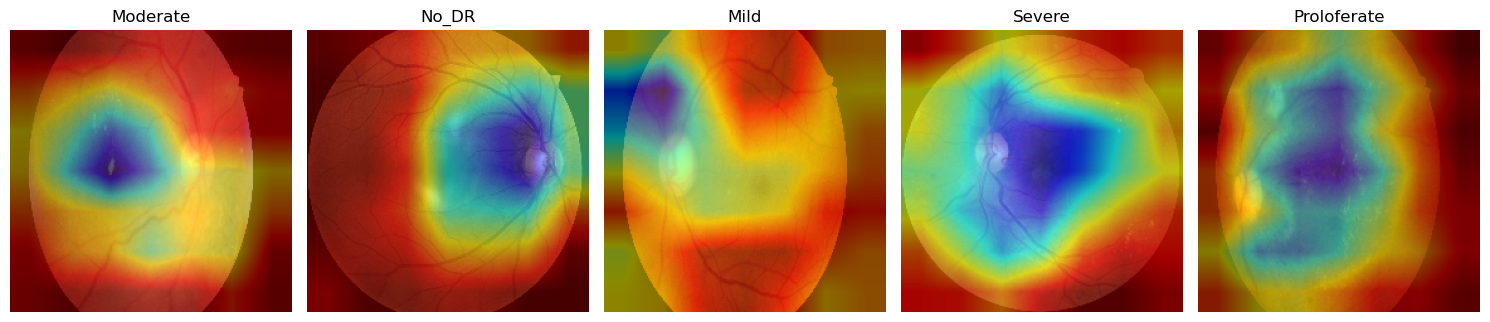

In [22]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        
        self.gradients = None
        self.activations = None
        
        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate(self, input_tensor, class_idx):
        self.model.zero_grad()
        
        output = self.model(input_tensor)
        loss = output[:, class_idx]
        loss.backward()
        
        grads = self.gradients
        activations = self.activations
        
        weights = torch.mean(grads, dim=(2,3), keepdim=True)
        cam = torch.sum(weights * activations, dim=1)
        
        cam = F.relu(cam)
        cam = cam.squeeze().cpu().detach().numpy()
        
        cam = (cam - cam.min()) / (cam.max() + 1e-8)
        return cam

class ResNetClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = models.resnet18(weights="IMAGENET1K_V1")
        self.model.fc = nn.Linear(512, 5)

    def forward(self, x):
        return self.model(x)

grad_model = ResNetClassifier().to(device)
grad_model.eval()

def get_one_per_class(images, labels):
    selected = {}
    
    for img, label in zip(images, labels):
        if label not in selected:
            selected[label] = img
        if len(selected) == 5:
            break
    
    return selected

sample_images = get_one_per_class(test_images, test_labels)

target_layer = grad_model.model.layer4[-1]
cam = GradCAM(grad_model, target_layer)

import cv2

def show_cam(image, cam_map, title="Grad-CAM"):
    img = (image / 255.0)
    
    cam_map = cv2.resize(cam_map, (224,224))
    heatmap = cv2.applyColorMap(np.uint8(255*cam_map), cv2.COLORMAP_JET)
    heatmap = heatmap / 255.0
    
    overlay = heatmap + img
    overlay = overlay / np.max(overlay)
    
    plt.imshow(overlay)
    plt.title(title)
    plt.axis('off')

    class_names = ['Mild', 'Moderate', 'No_DR', 'Proliferate', 'Severe']

plt.figure(figsize=(15,5))

for i, (label, img) in enumerate(sample_images.items()):
    
    input_tensor = torch.tensor(img, dtype=torch.float32).permute(2,0,1).unsqueeze(0).to(device) / 255.0
    
    output = grad_model(input_tensor)
    pred_class = torch.argmax(output).item()
    
    cam_map = cam.generate(input_tensor, pred_class)
    
    plt.subplot(1,5,i+1)
    show_cam(img, cam_map, f"{class_names[label]}")

plt.tight_layout()
plt.show()

In [24]:
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

def compute_accuracy(logits, labels):
    preds = coral_to_label(logits)
    correct = (preds == labels).sum().item()
    return correct / len(labels)

EPOCHS = 10

for epoch in range(EPOCHS):
    
    # -------- TRAIN --------
    model.train()
    train_loss = 0
    train_correct = 0
    total_train = 0
    
    for data in train_loader:
        data = data.to(device)
        optimizer.zero_grad()
        
        logits = model(data.x, data.edge_index, data.batch)
        loss = coral_loss(logits, data.y)
        
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        
        preds = coral_to_label(logits)
        train_correct += (preds == data.y).sum().item()
        total_train += data.y.size(0)
    
    train_loss /= len(train_loader)
    train_acc = train_correct / total_train
    
    # -------- VALIDATION --------
    model.eval()
    val_loss = 0
    val_correct = 0
    total_val = 0
    
    with torch.no_grad():
        for data in val_loader:
            data = data.to(device)
            
            logits = model(data.x, data.edge_index, data.batch)
            loss = coral_loss(logits, data.y)
            
            val_loss += loss.item()
            
            preds = coral_to_label(logits)
            val_correct += (preds == data.y).sum().item()
            total_val += data.y.size(0)
    
    val_loss /= len(val_loader)
    val_acc = val_correct / total_val
    
    # Save history
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)
    
    print(f"Epoch {epoch+1}")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
    print("-"*40)

plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies, label='Val Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

AttributeError: 'tuple' object has no attribute 'size'

## Preparing test set

In [33]:
test_iter = test.as_numpy_iterator()

In [35]:
y_true = test_set['labels']

In [2]:
import tensorflow as tf
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch_geometric.data import Data, DataLoader
from torch.nn import Conv2d
import matplotlib.pyplot as plt

# Generating train dataset
train_data = tf.keras.utils.image_dataset_from_directory(
    directory='D1',
    color_mode='rgb',
    batch_size=64,
    image_size=(224, 224),
    shuffle=True,
    seed=2022,
    labels='inferred',
    label_mode='int',
    class_names=['Mild', 'Moderate', 'No_DR', 'Proliferate', 'Severe']
)

# Prepare the train dataset for RGCNN
train_images = []
train_labels = []
for images, labels in train_data:
    train_images.append(images)
    train_labels.append(labels)
train_images = np.concatenate(train_images)
train_labels = np.concatenate(train_labels)

# Split the data into train and validation sets
train_split = int(0.7 * len(train_images))
val_images = train_images[train_split:]
val_labels = train_labels[train_split:]
train_images = train_images[:train_split]
train_labels = train_labels[:train_split]

# Convert train images to graph data
train_graphs = []
for i in range(len(train_images)):
    x = torch.tensor(train_images[i], dtype=torch.float32) / 255.0
    if len(x.shape) == 3:
        x = x.permute(2, 0, 1)
        x = x.unsqueeze(0)  # Add batch dimension
    elif len(x.shape) == 4:
        x = x.permute(0, 3, 1, 2)
    num_nodes = x.shape[0]  # Get the number of nodes in the graph
    edge_index = torch.tensor([[0, 1, 2, 3], [1, 0, 3, 2]], dtype=torch.long)  # Example edge index, adjust according to your graph structure
    edge_type = torch.tensor([0, 0, 1, 1], dtype=torch.long)  # Example edge types, adjust according to your graph structure
    y = torch.tensor(train_labels[i], dtype=torch.long)

    # Adjust the edge indices to match the number of nodes in the graph
    edge_index = edge_index % num_nodes

    train_graphs.append(Data(x=x, edge_index=edge_index, edge_type=edge_type, y=y))
train_dataset = DataLoader(train_graphs, batch_size=16, shuffle=True)

# Convert validation images to graph data
val_graphs = []
for i in range(len(val_images)):
    x = torch.tensor(val_images[i], dtype=torch.float32) / 255.0
    if len(x.shape) == 3:
        x = x.permute(2, 0, 1)
        x = x.unsqueeze(0)  # Add batch dimension
    elif len(x.shape) == 4:
        x = x.permute(0, 3, 1, 2)
    num_nodes = x.shape[0]  # Get the number of nodes in the graph
    edge_index = torch.tensor([[0, 1, 2, 3], [1, 0, 3, 2]], dtype=torch.long)  # Example edge index, adjust according to your graph structure
    edge_type = torch.tensor([0, 0, 1, 1], dtype=torch.long)  # Example edge types, adjust according to your graph structure
    y = torch.tensor(val_labels[i], dtype=torch.long)

    # Adjust the edge indices to match the number of nodes in the graph
    edge_index = edge_index % num_nodes

    val_graphs.append(Data(x=x, edge_index=edge_index, edge_type=edge_type, y=y))
val_dataset = DataLoader(val_graphs, batch_size=16, shuffle=False)


# Define the RGCNN model
class RGCNN(nn.Module):
    def __init__(self, num_classes):
        super(RGCNN, self).__init__()
        self.conv1 = Conv2d(in_channels=3, out_channels=16, kernel_size=3, stride=1, padding=1)
        self.conv2 = Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1)
        self.fc = nn.Linear(32 * 224 * 224, num_classes)

    def forward(self, x):
        x = self.conv1(x)
        x = torch.relu(x)
        x = self.conv2(x)
        x = torch.relu(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

Found 3662 files belonging to 5 classes.


C:\Users\abisw\anaconda3\lib\site-packages\torch_geometric\deprecation.py:22: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


Found 3662 files belonging to 5 classes.
Epoch 1:
Train Loss: 1.7641 | Train Accuracy: 0.6844
Val Loss: 0.7893 | Val Accuracy: 0.7252

Epoch 2:
Train Loss: 0.7073 | Train Accuracy: 0.7429
Val Loss: 0.7665 | Val Accuracy: 0.7207

Epoch 3:
Train Loss: 0.6168 | Train Accuracy: 0.7792
Val Loss: 0.8895 | Val Accuracy: 0.6952

Epoch 4:
Train Loss: 0.4934 | Train Accuracy: 0.8264
Val Loss: 1.2149 | Val Accuracy: 0.6497

Epoch 5:
Train Loss: 0.5162 | Train Accuracy: 0.8166
Val Loss: 1.0416 | Val Accuracy: 0.5805

Epoch 6:
Train Loss: 0.4991 | Train Accuracy: 0.8182
Val Loss: 0.7630 | Val Accuracy: 0.7334

Epoch 7:
Train Loss: 0.3908 | Train Accuracy: 0.8705
Val Loss: 0.9910 | Val Accuracy: 0.7361

Epoch 8:
Train Loss: 0.1949 | Train Accuracy: 0.9469
Val Loss: 1.3800 | Val Accuracy: 0.7480

Epoch 9:
Train Loss: 0.1182 | Train Accuracy: 0.9778
Val Loss: 1.1472 | Val Accuracy: 0.7507

Epoch 10:
Train Loss: 0.0829 | Train Accuracy: 0.9891
Val Loss: 0.9496 | Val Accuracy: 0.7334



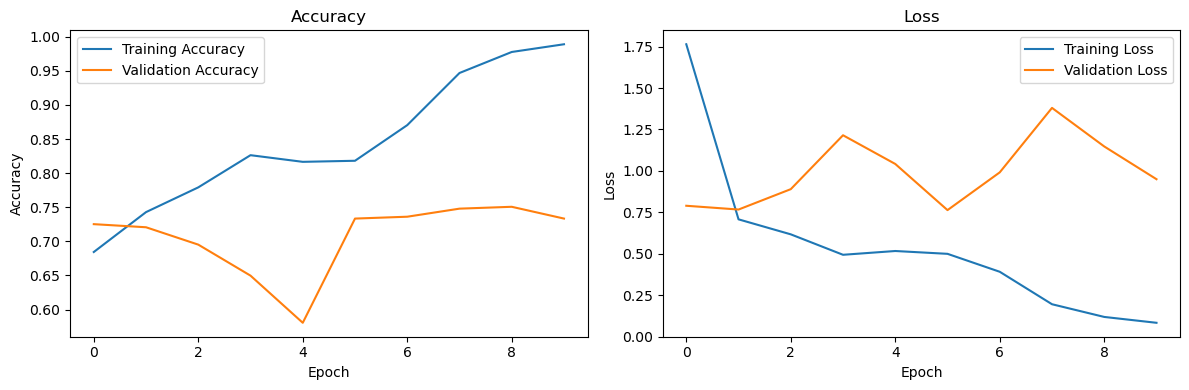

In [40]:
import tensorflow as tf
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch_geometric.data import Data, DataLoader
from torch.nn import Conv2d
import matplotlib.pyplot as plt

# Generating train dataset
train_data = tf.keras.utils.image_dataset_from_directory(
    directory='D1',
    color_mode='rgb',
    batch_size=64,
    image_size=(224, 224),
    shuffle=True,
    seed=2022,
    labels='inferred',
    label_mode='int',
    class_names=['Mild', 'Moderate', 'No_DR', 'Proliferate', 'Severe']
)

# Prepare the train dataset for RGCNN
train_images = []
train_labels = []
for images, labels in train_data:
    train_images.append(images)
    train_labels.append(labels)
train_images = np.concatenate(train_images)
train_labels = np.concatenate(train_labels)

# Split the data into train and validation sets
train_split = int(0.7 * len(train_images))
val_images = train_images[train_split:]
val_labels = train_labels[train_split:]
train_images = train_images[:train_split]
train_labels = train_labels[:train_split]

# Convert train images to graph data
train_graphs = []
for i in range(len(train_images)):
    x = torch.tensor(train_images[i], dtype=torch.float32) / 255.0
    if len(x.shape) == 3:
        x = x.permute(2, 0, 1)
        x = x.unsqueeze(0)  # Add batch dimension
    elif len(x.shape) == 4:
        x = x.permute(0, 3, 1, 2)
    num_nodes = x.shape[0]  # Get the number of nodes in the graph
    edge_index = torch.tensor([[0, 1, 2, 3], [1, 0, 3, 2]], dtype=torch.long)  # Example edge index, adjust according to your graph structure
    edge_type = torch.tensor([0, 0, 1, 1], dtype=torch.long)  # Example edge types, adjust according to your graph structure
    y = torch.tensor(train_labels[i], dtype=torch.long)

    # Adjust the edge indices to match the number of nodes in the graph
    edge_index = edge_index % num_nodes

    train_graphs.append(Data(x=x, edge_index=edge_index, edge_type=edge_type, y=y))
train_dataset = DataLoader(train_graphs, batch_size=16, shuffle=True)

# Convert validation images to graph data
val_graphs = []
for i in range(len(val_images)):
    x = torch.tensor(val_images[i], dtype=torch.float32) / 255.0
    if len(x.shape) == 3:
        x = x.permute(2, 0, 1)
        x = x.unsqueeze(0)  # Add batch dimension
    elif len(x.shape) == 4:
        x = x.permute(0, 3, 1, 2)
    num_nodes = x.shape[0]  # Get the number of nodes in the graph
    edge_index = torch.tensor([[0, 1, 2, 3], [1, 0, 3, 2]], dtype=torch.long)  # Example edge index, adjust according to your graph structure
    edge_type = torch.tensor([0, 0, 1, 1], dtype=torch.long)  # Example edge types, adjust according to your graph structure
    y = torch.tensor(val_labels[i], dtype=torch.long)

    # Adjust the edge indices to match the number of nodes in the graph
    edge_index = edge_index % num_nodes

    val_graphs.append(Data(x=x, edge_index=edge_index, edge_type=edge_type, y=y))
val_dataset = DataLoader(val_graphs, batch_size=16, shuffle=False)


# Define the RGCNN model
class RGCNN(nn.Module):
    def __init__(self, num_classes):
        super(RGCNN, self).__init__()
        self.conv1 = Conv2d(in_channels=3, out_channels=16, kernel_size=3, stride=1, padding=1)
        self.conv2 = Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1)
        self.fc = nn.Linear(32 * 224 * 224, num_classes)

    def forward(self, x):
        x = self.conv1(x)
        x = torch.relu(x)
        x = self.conv2(x)
        x = torch.relu(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

# Initialize the RGCNN model
model = RGCNN(num_classes=5)

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop
train_loss_history = []
train_accuracy_history = []
val_loss_history = []
val_accuracy_history = []

for epoch in range(10):
    model.train()
    epoch_train_loss = 0.0
    epoch_train_correct = 0

    for data in train_dataset:
        optimizer.zero_grad()
        output = model(data.x)
        loss = criterion(output, data.y)
        loss.backward()
        optimizer.step()

        _, predicted = torch.max(output, 1)
        epoch_train_loss += loss.item() * data.num_graphs
        epoch_train_correct += (predicted == data.y).sum().item()

    train_loss = epoch_train_loss / len(train_images)
    train_accuracy = epoch_train_correct / len(train_images)

    train_loss_history.append(train_loss)
    train_accuracy_history.append(train_accuracy)

    model.eval()
    epoch_val_loss = 0.0
    epoch_val_correct = 0

    for data in val_dataset:
        output = model(data.x)
        loss = criterion(output, data.y)

        _, predicted = torch.max(output, 1)
        epoch_val_loss += loss.item() * data.num_graphs
        epoch_val_correct += (predicted == data.y).sum().item()

    val_loss = epoch_val_loss / len(val_images)
    val_accuracy = epoch_val_correct / len(val_images)

    val_loss_history.append(val_loss)
    val_accuracy_history.append(val_accuracy)

    # Print the loss and accuracy for each epoch
    print(f"Epoch {epoch + 1}:")
    print(f"Train Loss: {train_loss:.4f} | Train Accuracy: {train_accuracy:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Val Accuracy: {val_accuracy:.4f}")
    print()

# Plot the accuracy and loss graphs
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_accuracy_history, label='Training Accuracy')
plt.plot(val_accuracy_history, label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_loss_history, label= 'Training Loss')
plt.plot(val_loss_history, label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

In [55]:
import tensorflow as tf
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch_geometric.data import Data, DataLoader
from torch.nn import Conv2d
from sklearn.metrics import classification_report, confusion_matrix

# Generating train dataset
data = tf.keras.utils.image_dataset_from_directory(
    directory='D1',
    color_mode='rgb',
    batch_size=64,
    image_size=(224, 224),
    shuffle=True,
    seed=2022,
    labels='inferred',
    label_mode='int',
    class_names=['Mild', 'Moderate', 'No_DR', 'Proliferate', 'Severe']
)

# Split the data into train, validation, and test sets
train_size = int(0.7 * len(data))
val_size = int(0.2 * len(data))
test_size = int(0.1 * len(data))

train_data = data.take(train_size)
remaining = data.skip(train_size)
val_data = remaining.take(val_size)
test_data = remaining.skip(val_size)

# Prepare the train dataset for RGCNN
train_images = []
train_labels = []
for images, labels in train_data:
    train_images.append(images)
    train_labels.append(labels)
train_images = np.concatenate(train_images)
train_labels = np.concatenate(train_labels)

# Convert train images to graph data
train_graphs = []
for i in range(len(train_images)):
    x = torch.tensor(train_images[i], dtype=torch.float32) / 255.0
    if len(x.shape) == 3:
        x = x.permute(2, 0, 1)
        x = x.unsqueeze(0)  # Add batch dimension
    elif len(x.shape) == 4:
        x = x.permute(0, 3, 1, 2)
    num_nodes = x.shape[0]  # Get the number of nodes in the graph
    edge_index = torch.tensor([[0, 1, 2, 3], [1, 0, 3, 2]], dtype=torch.long)  # Example edge index, adjust according to your graph structure
    edge_type = torch.tensor([0, 0, 1, 1], dtype=torch.long)  # Example edge types, adjust according to your graph structure
    y = torch.tensor(train_labels[i], dtype=torch.long)

    # Adjust the edge indices to match the number of nodes in the graph
    edge_index = edge_index % num_nodes

    train_graphs.append(Data(x=x, edge_index=edge_index, edge_type=edge_type, y=y))
train_dataset = DataLoader(train_graphs, batch_size=16, shuffle=True)

# Convert validation images to graph data
val_images = []
val_labels = []
for images, labels in val_data:
    val_images.append(images)
    val_labels.append(labels)
val_images = np.concatenate(val_images)
val_labels = np.concatenate(val_labels)

val_graphs = []
for i in range(len(val_images)):
    x = torch.tensor(val_images[i], dtype=torch.float32) / 255.0
    if len(x.shape) == 3:
        x = x.permute(2, 0, 1)
        x = x.unsqueeze(0)  # Add batch dimension
    elif len(x.shape) == 4:
        x = x.permute(0, 3, 1, 2)
    num_nodes = x.shape[0]  # Get the number of nodes in the graph
    edge_index = torch.tensor([[0, 1, 2, 3], [1, 0, 3, 2]], dtype=torch.long)  # Example edge index, adjust according to your graph structure
    edge_type = torch.tensor([0, 0, 1, 1], dtype=torch.long)  # Example edge types, adjust according to your graph structure
    y = torch.tensor(val_labels[i], dtype=torch.long)

    # Adjust the edge indices to match the number of nodes in the graph
    edge_index = edge_index % num_nodes

    val_graphs.append(Data(x=x, edge_index=edge_index, edge_type=edge_type, y=y))
val_dataset = DataLoader(val_graphs, batch_size=16, shuffle=False)

# Define the RGCNN model
class RGCNN(nn.Module):
    def __init__(self, num_classes):
        super(RGCNN, self).__init__()
        self.conv1 = Conv2d(in_channels=3, out_channels=16, kernel_size=3, stride=1, padding=1)
        self.conv2 = Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1)
        self.fc = nn.Linear(32 * 224 * 224, num_classes)

    def forward(self, x):
        x = self.conv1(x)
        x = torch.relu(x)
        x = self.conv2(x)
        x = torch.relu(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

# Initialize the RGCNN model
model = RGCNN(num_classes=5)

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop
for epoch in range(10):
    model.train()
    for data in train_dataset:
        optimizer.zero_grad()
        output = model(data.x)
        loss = criterion(output, data.y)
        loss.backward()
        optimizer.step()

    # Validation
    model.eval()
    val_loss = 0.0
    val_correct = 0

    for data in val_dataset:
        output = model(data.x)
        loss = criterion(output, data.y)

        _, predicted = torch.max(output, 1)
        val_loss += loss.item() * data.num_graphs
        val_correct += (predicted == data.y).sum().item()

    val_loss /= len(val_dataset)
    val_accuracy = val_correct / len(val_images)

    # Print the loss and accuracy for each epoch
    print(f"Epoch {epoch + 1}:")
    print(f"Validation Loss: {val_loss:.4f} | Validation Accuracy: {val_accuracy:.4f}")
    print()

# Testing
test_images = []
test_labels = []
for images, labels in test_data:
    test_images.append(images)
    test_labels.append(labels)
test_images = np.concatenate(test_images)
test_labels = np.concatenate(test_labels)

test_graphs = []
for i in range(len(test_images)):
    x = torch.tensor(test_images[i], dtype=torch.float32) / 255.0
    if len(x.shape) == 3:
        x = x.permute(2, 0, 1)
        x = x.unsqueeze(0)  # Add batch dimension
    elif len(x.shape) == 4:
        x = x.permute(0, 3, 1, 2)
    num_nodes = x.shape[0]  # Get the number of nodes in the graph
    edge_index = torch.tensor([[0, 1, 2, 3], [1, 0, 3, 2]], dtype=torch.long)  # Example edge index, adjust according to your graph structure
    edge_type = torch.tensor([0, 0, 1, 1], dtype=torch.long)  # Example edge types, adjust according to your graph structure
    y = torch.tensor(test_labels[i], dtype=torch.long)

    # Adjust the edge indices to match the number of nodes in the graph
    edge_index = edge_index % num_nodes

    test_graphs.append(Data(x=x, edge_index=edge_index, edge_type=edge_type, y=y))
test_dataset = DataLoader(test_graphs, batch_size=16, shuffle=False)

# Testing evaluation
model.eval()
test_loss = 0.0
test_correct = 0

for data in test_dataset:
    output = model(data.x)
    loss = criterion(output, data.y)

    _, predicted = torch.max(output, 1)
    test_loss += loss.item() * data.num_graphs
    test_correct += (predicted == data.y).sum().item()

test_loss /= len(test_dataset)
test_accuracy = test_correct / len(test_images)

# Print the test loss and accuracy
print(f"Test Loss: {test_loss:.4f} | Test Accuracy: {test_accuracy:.4f}")

# Compute classification report and confusion matrix
y_true = []
y_pred = []

for data in test_dataset:
    output = model(data.x)
    _, predicted = torch.max(output, 1)
    y_true.extend(data.y.tolist())
    y_pred.extend(predicted.tolist())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

report = classification_report(y_true, y_pred)
confusion_mat = confusion_matrix(y_true, y_pred)

print("Classification Report:")
print(report)
print("Confusion Matrix:")
print(confusion_mat)

Found 3662 files belonging to 5 classes.
Epoch 1:
Validation Loss: 12.9272 | Validation Accuracy: 0.7145

Epoch 2:
Validation Loss: 12.4094 | Validation Accuracy: 0.7415

Epoch 3:
Validation Loss: 12.2427 | Validation Accuracy: 0.7614

Epoch 4:
Validation Loss: 12.5437 | Validation Accuracy: 0.7898

Epoch 5:
Validation Loss: 13.9323 | Validation Accuracy: 0.7670

Epoch 6:
Validation Loss: 13.9756 | Validation Accuracy: 0.7884

Epoch 7:
Validation Loss: 12.7266 | Validation Accuracy: 0.7869

Epoch 8:
Validation Loss: 15.2686 | Validation Accuracy: 0.8068

Epoch 9:
Validation Loss: 15.5098 | Validation Accuracy: 0.7912

Epoch 10:
Validation Loss: 13.6404 | Validation Accuracy: 0.8040

Test Loss: 13.6639 | Test Accuracy: 0.7714
Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.30      0.39        44
           1       0.60      0.80      0.69       105
           2       0.93      0.99      0.96       192
           3       0.65  

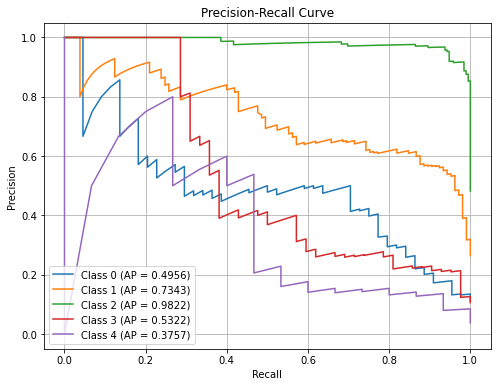

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

# Compute the predicted probabilities for each class
y_probs = []
y_true = []

for data in test_dataset:
    output = model(data.x)
    probs = torch.softmax(output, dim=1)
    y_probs.extend(probs.detach().numpy())
    y_true.extend(data.y.tolist())

y_probs = np.array(y_probs)
y_true = np.array(y_true)

# Compute the precision-recall curve and average precision scores for each class
precision_scores = []
recall_scores = []
average_precision_scores = []

for class_idx in range(y_probs.shape[1]):
    y_true_class = y_true == class_idx
    y_probs_class = y_probs[:, class_idx]
    precision, recall, _ = precision_recall_curve(y_true_class, y_probs_class)
    average_precision = average_precision_score(y_true_class, y_probs_class)
    precision_scores.append(precision)
    recall_scores.append(recall)
    average_precision_scores.append(average_precision)

# Plot the precision-recall curves
plt.figure(figsize=(8, 6))
for class_idx in range(y_probs.shape[1]):
    plt.plot(recall_scores[class_idx], precision_scores[class_idx], label=f"Class {class_idx} (AP = {average_precision_scores[class_idx]:.4f})")

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.grid(True)
plt.show()

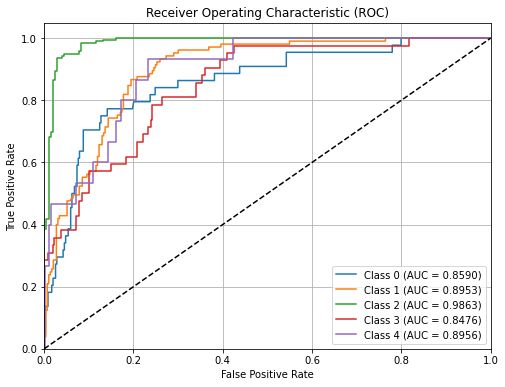

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Compute the predicted probabilities for each class
y_probs = []
y_true = []

for data in test_dataset:
    output = model(data.x)
    probs = torch.softmax(output, dim=1)
    y_probs.extend(probs.detach().numpy())
    y_true.extend(data.y.tolist())

y_probs = np.array(y_probs)
y_true = np.array(y_true)

# Binarize the true labels
y_true_bin = label_binarize(y_true, classes=np.arange(5))  # Assuming 5 classes

# Compute the ROC curve and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for class_idx in range(y_probs.shape[1]):
    fpr[class_idx], tpr[class_idx], _ = roc_curve(y_true_bin[:, class_idx], y_probs[:, class_idx])
    roc_auc[class_idx] = auc(fpr[class_idx], tpr[class_idx])

# Compute the micro-average ROC curve and AUC
fpr_micro, tpr_micro, _ = roc_curve(y_true_bin.ravel(), y_probs.ravel())
roc_auc_micro = auc(fpr_micro, tpr_micro)

# Plot the ROC curves
plt.figure(figsize=(8, 6))
for class_idx in range(y_probs.shape[1]):
    plt.plot(fpr[class_idx], tpr[class_idx], label=f"Class {class_idx} (AUC = {roc_auc[class_idx]:.4f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()